# Model Evaluation and Experimentation

Goal:
Evaluate different feature representations for anomaly detection
on the NASA C-MAPSS FD003 dataset.

Experiments:

1. Important Sensors
2. PCA(2)
3. PCA(5)
4. All Useful Sensors

Model:
Isolation Forest

Evaluation:
- ROC-AUC
- Precision
- Recall
- Anomaly Score vs RUL

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

from sklearn.metrics import roc_auc_score

train_df = pd.read_csv(
    "../data/processed/train/fd003_healthy_baseline.csv"
)

eval_df = pd.read_csv(
    "../data/processed/train/fd003_with_rul.csv"
)

print(train_df.shape)
print(eval_df.shape)

(5000, 31)
(24720, 31)


In [7]:
important_sensors = [
    "sensor_11",
    "sensor_4",
    "sensor_13",
    "sensor_8",
    "sensor_17",
    "sensor_3",
    "sensor_2",
    "sensor_9"
]

X_train = train_df[important_sensors]

X_train.head()

,sensor_11,sensor_4,sensor_13,sensor_8,sensor_17,sensor_3,sensor_2,sensor_9
0,47.30,1396.84,2388.01,2387.96,391,1583.23,642.36,9062.17
1,47.23,1396.89,2388.03,2388.00,392,1584.69,642.50,9061.78
2,47.22,1405.61,2388.00,2388.03,391,1582.35,642.18,9070.23
3,47.24,1392.27,2388.08,2388.00,392,1585.61,642.92,9064.57
4,47.15,1397.65,2388.03,2388.04,392,1588.63,641.68,9076.14


X_train = train_df[important_sensors]

X_train.head()

In [8]:
scaler = StandardScaler()


In [9]:
X_train_scaled = scaler.fit_transform(X_train)

In [10]:
X_train_scaled = scaler.fit_transform(X_train)

In [11]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42
)

In [12]:
model.fit(X_train_scaled)

,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.01
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [13]:
X_eval = eval_df[important_sensors]

X_eval_scaled = scaler.transform(X_eval)

In [14]:
anomaly_scores = -model.score_samples(
    X_eval_scaled
)

In [15]:
eval_df["anomaly_score"] = anomaly_scores


In [16]:
eval_df[
    ["RUL", "anomaly_score"]
].head()

,RUL,anomaly_score
0,258,0.384818
1,257,0.383697
2,256,0.424650
3,255,0.439994
4,254,0.449165


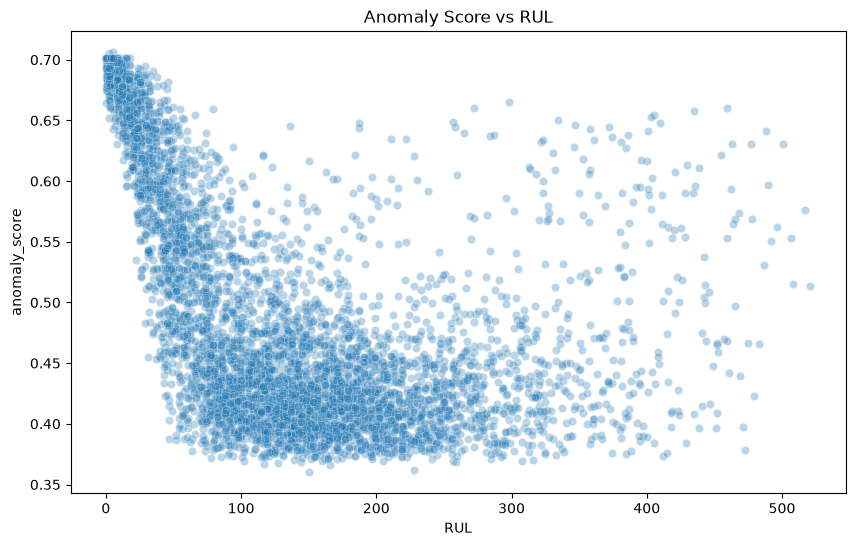

In [17]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=eval_df.sample(5000),
    x="RUL",
    y="anomaly_score",
    alpha=0.3
)

plt.title(
    "Anomaly Score vs RUL"
)

plt.show()

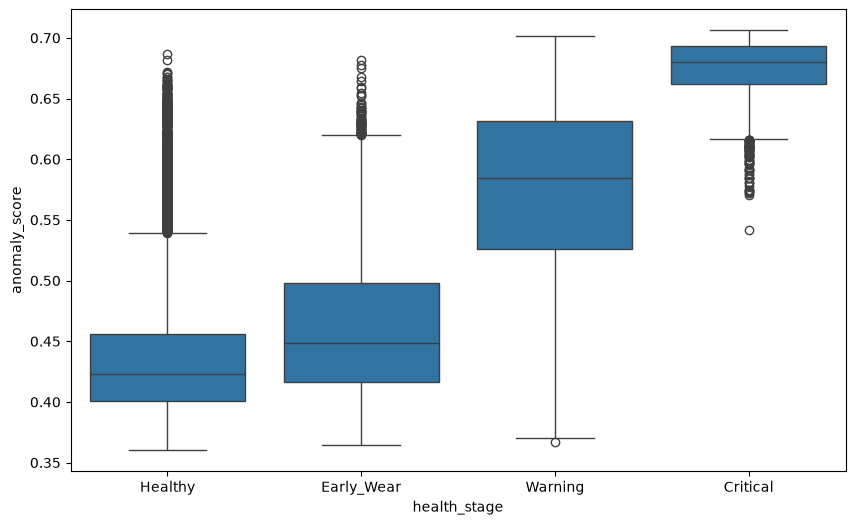

In [18]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=eval_df,
    x="health_stage",
    y="anomaly_score",
    order=[
        "Healthy",
        "Early_Wear",
        "Warning",
        "Critical"
    ]
)

plt.show()

In [19]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    eval_df["anomaly_label"],
    eval_df["anomaly_score"]
)

print(auc)

0.982567865775417


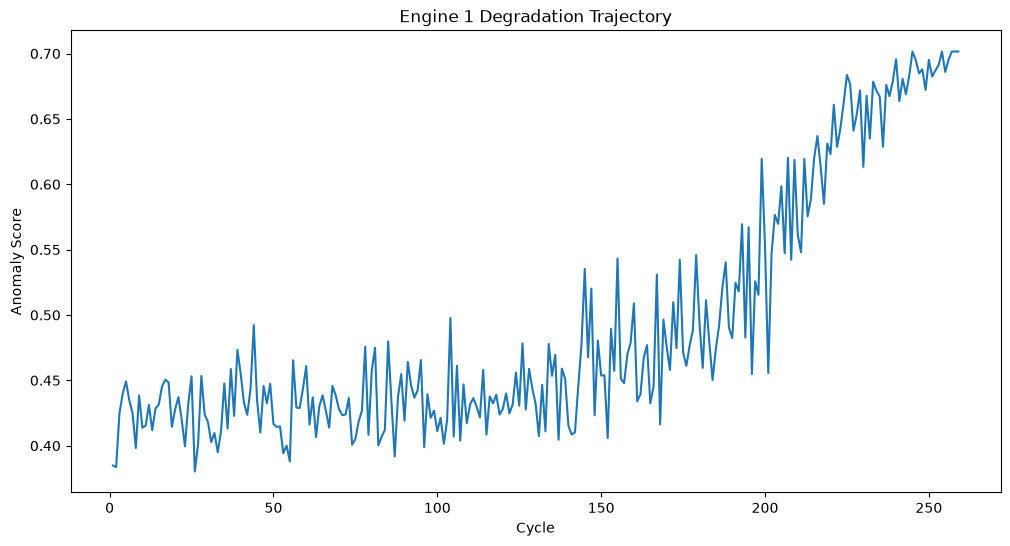

In [20]:
engine = eval_df[
    eval_df["engine_id"] == 1
]

plt.figure(figsize=(12,6))

plt.plot(
    engine["cycle"],
    engine["anomaly_score"]
)

plt.xlabel("Cycle")
plt.ylabel("Anomaly Score")
plt.title("Engine 1 Degradation Trajectory")

plt.show()